 ## AIAA 3201 Project 4
 ### README
 - This notebook should be run on Google Colab using GPU.
 - In part 1.1, the code for COLMAP, VGGT and dust3r is runnable. The code for mapanything and Pi3 has errors in installation, and the runner is unchecked.
 - In part 1.2, some cells are not run as I'm run out of GPU time in Google Colab. Hope that it does not have directory issues or other bugs.
 - There's still a long way to completion of part 1 & 2, with is required in the presentation. Hope that you can make it on time.

 ## Part 1.1 Initialization through colmap, VGGT and dust3r

In [2]:
import os
import sys
import torch
import subprocess
from pathlib import Path

# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Create workspace directories
WORKSPACE = "/content/3d_reconstruction_experiment"
DRIVE_WORKSPACE = "/content/drive/MyDrive/AIAA3201_project"

os.makedirs(WORKSPACE, exist_ok=True)
os.makedirs(DRIVE_WORKSPACE, exist_ok=True)

print(f"Workspace: {WORKSPACE}")
print(f"Drive backup: {DRIVE_WORKSPACE}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

Mounted at /content/drive
Workspace: /content/3d_reconstruction_experiment
Drive backup: /content/drive/MyDrive/AIAA3201_project
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [3]:
# install_colmap_complete.py
"""
Complete COLMAP installation for Google Colab
Run this cell first before running the experiment
"""

import subprocess
import sys
import os
from pathlib import Path

def install_colmap_complete():
    print("="*60)
    print("Installing COLMAP for Google Colab")
    print("="*60)

    # Method 1: Install via apt-get (most reliable in Colab)
    print("\n[Method 1] Installing via apt-get...")
    try:
        # Update package list
        subprocess.run(["sudo", "apt-get", "update"], check=True, capture_output=True)

        # Install COLMAP and dependencies
        subprocess.run(["sudo", "apt-get", "install", "-y",
                       "colmap",
                       "libgoogle-glog-dev",
                       "libgflags-dev",
                       "libatlas-base-dev",
                       "libeigen3-dev",
                       "libsuitesparse-dev"],
                      check=True, capture_output=True)

        print("✓ COLMAP installed successfully via apt-get")
        return True

    except subprocess.CalledProcessError as e:
        print(f"  apt-get installation failed: {e}")

    # Method 2: Build from source (fallback)
    print("\n[Method 2] Building COLMAP from source...")
    try:
        # Install build dependencies
        subprocess.run(["sudo", "apt-get", "install", "-y",
                       "build-essential",
                       "cmake",
                       "git",
                       "libceres-dev",
                       "libqt5opengl5-dev",
                       "libqt5x11extras5-dev",
                       "libboost-program-options-dev",
                       "libboost-filesystem-dev",
                       "libboost-graph-dev",
                       "libboost-system-dev",
                       "libboost-test-dev",
                       "libboost-thread-dev",
                       "libflann-dev",
                       "libfreeimage-dev",
                       "libmetis-dev",
                       "libgoogle-glog-dev",
                       "libgflags-dev",
                       "libglew-dev",
                       "qtbase5-dev",
                       "libqt5opengl5-dev",
                       "libcgal-dev"],
                      check=True, capture_output=True)

        # Clone COLMAP repository
        if not Path("/content/colmap").exists():
            subprocess.run(["git", "clone", "https://github.com/colmap/colmap.git"],
                          cwd="/content", check=True, capture_output=True)

        # Build COLMAP
        subprocess.run(["mkdir", "-p", "build"], cwd="/content/colmap", check=True)
        subprocess.run(["cmake", ".."], cwd="/content/colmap/build", check=True, capture_output=True)
        subprocess.run(["make", "-j", "4"], cwd="/content/colmap/build", check=True, capture_output=True)
        subprocess.run(["sudo", "make", "install"], cwd="/content/colmap/build", check=True, capture_output=True)

        print("✓ COLMAP built from source successfully")
        return True

    except subprocess.CalledProcessError as e:
        print(f"  Source build failed: {e}")

    # Method 3: Use conda if available
    print("\n[Method 3] Installing via conda...")
    try:
        # Check if conda is available
        result = subprocess.run(["which", "conda"], capture_output=True, text=True)
        if result.returncode == 0:
            subprocess.run(["conda", "install", "-c", "conda-forge", "colmap", "-y"],
                          check=True, capture_output=True)
            print("✓ COLMAP installed via conda")
            return True
        else:
            print("  Conda not available")
    except:
        print("  Conda installation failed")

    print("\n❌ All installation methods failed")
    return False

def verify_colmap():
    """Verify COLMAP installation"""
    print("\n" + "="*60)
    print("Verifying COLMAP Installation")
    print("="*60)

    # Check common paths
    colmap_paths = [
        "/usr/bin/colmap",
        "/usr/local/bin/colmap",
        "/content/colmap/build/src/colmap",
        "/content/colmap/build/src/exe/colmap"
    ]

    for path in colmap_paths:
        if Path(path).exists():
            print(f"✓ COLMAP found at: {path}")
            # Test COLMAP
            try:
                result = subprocess.run([path, "-h"], capture_output=True, text=True)
                if result.returncode == 0:
                    print("✓ COLMAP is working")
                    return path
            except:
                pass

    # Try which command
    result = subprocess.run(["which", "colmap"], capture_output=True, text=True)
    if result.returncode == 0:
        path = result.stdout.strip()
        print(f"✓ COLMAP found at: {path}")
        return path

    print("❌ COLMAP not found")
    return None

# Run installation
if __name__ == "__main__":
    success = install_colmap_complete()
    if success:
        colmap_path = verify_colmap()
        if colmap_path:
            print(f"\n✅ COLMAP is ready to use at: {colmap_path}")
        else:
            print("\n⚠️ COLMAP installed but verification failed")
    else:
        print("\n❌ COLMAP installation failed")

Installing COLMAP for Google Colab

[Method 1] Installing via apt-get...
✓ COLMAP installed successfully via apt-get

Verifying COLMAP Installation
✓ COLMAP found at: /usr/bin/colmap
✓ COLMAP is working

✅ COLMAP is ready to use at: /usr/bin/colmap


In [5]:
# Update pip and install basic dependencies
#!pip install --upgrade pip
#!pip install numpy opencv-python-headless pillow scipy matplotlib tqdm

# Install COLMAP (using conda since it's easier on Colab)
!wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O miniconda.sh
!bash miniconda.sh -b -p /content/miniconda
!export PATH="/content/miniconda/bin:$PATH"
!export PATH="/content/miniconda/condabin:$PATH"

# Install COLMAP via conda
!export PATH="/content/miniconda/bin:$PATH" && conda install -c conda-forge colmap -y

# Install pycolmap
!pip install pycolmap

ERROR: File or directory already exists: '/content/miniconda'
If you want to update an existing installation, use the -u option.
/bin/bash: line 1: conda: command not found


In [6]:
# Clone VGGT repository
!git clone https://github.com/facebookresearch/vggt.git /content/vggt
%cd /content/vggt

# Install dependencies
#!pip install -r requirements.txt
!pip install -e .

# Verify VGGT installation
import sys
sys.path.insert(0, '/content/vggt')
try:
    from vggt.models.vggt import VGGT
    print("✓ VGGT imported successfully")
except Exception as e:
    print(f"VGGT import error: {e}")

Cloning into '/content/vggt'...
remote: Enumerating objects: 1272, done.
remote: Counting objects: 100% (310/310), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 1272 (delta 238), reused 182 (delta 182), pack-reused 962 (from 1)
Receiving objects: 100% (1272/1272), 64.82 MiB | 27.25 MiB/s, done.
Resolving deltas: 100% (641/641), done.
/content/vggt
Obtaining file:///content/vggt
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 38.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 56.9 MB/s  0:00:01
  Building editable for vggt (pyproject.toml) ... done
  Created wheel for vggt: fil

✓ VGGT imported successfully


In [7]:
# Clone DUSt3R with submodules
!git clone --recursive https://github.com/naver/dust3r.git /content/dust3r
%cd /content/dust3r

# Create separate environment and install (using pip directly for simplicity)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
#!pip install -r requirements.txt
!pip install -e .

# Optional: Install open3d for visualization
!pip install open3d trimesh

# Verify DUSt3R
sys.path.insert(0, '/content/dust3r')
try:
    from dust3r.model import AsymmetricCroCo3DStereo
    print("✓ DUSt3R imported successfully")
except Exception as e:
    print(f"DUSt3R import error: {e}")

Cloning into '/content/dust3r'...
remote: Enumerating objects: 611, done.
remote: Total 611 (delta 0), reused 0 (delta 0), pack-reused 611 (from 1)
Receiving objects: 100% (611/611), 756.60 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (355/355), done.
Submodule 'croco' (https://github.com/naver/croco) registered for path 'croco'
Cloning into '/content/dust3r/croco'...
remote: Enumerating objects: 198, done.        
remote: Counting objects: 100% (89/89), done.        
remote: Compressing objects: 100% (55/55), done.        
remote: Total 198 (delta 56), reused 34 (delta 34), pack-reused 109 (from 1)        
Receiving objects: 100% (198/198), 403.77 KiB | 1.97 MiB/s, done.
Resolving deltas: 100% (95/95), done.
Submodule path 'croco': checked out 'd7de0705845239092414480bd829228723bf20de'
/content/dust3r
Looking in indexes: https://download.pytorch.org/whl/cu118
Obtaining file:///content/dust3r
ERROR: file:///content/dust3r does not appear to be a Python project: neither 'setup.py' nor

In [7]:
# Clone MapAnything repository
!git clone https://github.com/facebookresearch/map-anything.git /content/map-anything
%cd /content/map-anything

# Install with all dependencies
!pip install -e .

# Verify MapAnything
sys.path.insert(0, '/content/map-anything')
try:
    from mapanything.models import MapAnything
    print("✓ MapAnything imported successfully")
except Exception as e:
    print(f"MapAnything import error: {e}")

fatal: destination path '/content/map-anything' already exists and is not an empty directory.
/content/map-anything
Obtaining file:///content/map-anything
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mapanything (pyproject.toml) ... done
  Created wheel for mapanything: filename=mapanything-1.1-0.editable-py3-none-any.whl size=7597 sha256=edabd7393fc349aaa41a9ac38227890e2514f5f77b6d8d7ef6f9f5c5ec9d1235
  Stored in directory: /tmp/pip-ephem-wheel-cache-i72t6bqo/wheels/14/d9/ff/8c85544458d9ba5aff9362075fa770a60e3de0be3607119307
Successfully built mapanything
  Attempting uninstall: mapanything
    Found existing installation: mapanything 1.1
    Uninstalling mapanything-1.1:
      Successfully uninstalled mapanything-1.1


MapAnything import error: partially initialized module 'torchvision' has no attribute 'extension' (most likely due to a circular import)


In [10]:
# Clone Pi3 repository
!git clone https://github.com/yyfz/Pi3.git /content/Pi3
%cd /content/Pi3

# Install dependencies
#!pip install -r requirements.txt

# Verify Pi3
sys.path.insert(0, '/content/Pi3')
try:
    from pi3.models.pi3 import Pi3
    print("✓ Pi3 imported successfully")
except Exception as e:
    print(f"Pi3 import error: {e}")

# Return to workspace
%cd {WORKSPACE}


fatal: destination path '/content/Pi3' already exists and is not an empty directory.
/content/Pi3
Pi3 import error: 'pi3'
/content/3d_reconstruction_experiment


In [8]:

%%writefile {WORKSPACE}/prepare_datasets.py
WORKSPACE = "/content/3d_reconstruction_experiment"
DRIVE_WORKSPACE = "/content/drive/MyDrive/AIAA3201_project"
"""
Dataset preparation script for Waymo, Dl3dv, and Re10k
Creates sample data structures for testing
"""

import os
import cv2
import numpy as np
from pathlib import Path
import urllib.request
import zipfile
from tqdm import tqdm

def download_sample_images(output_dir, num_images=30):
    """Download sample images from a public dataset for testing"""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Use sample images from Hugging Face datasets (small for testing)
    # In production, you'd use your actual dataset paths
    print(f"Creating sample dataset at {output_dir}")

    # Create synthetic images if no real data available
    for i in range(num_images):
        # Create gradient image for testing
        img = np.zeros((480, 640, 3), dtype=np.uint8)
        for j in range(640):
            img[:, j] = [int(255 * j / 640), int(128 * (1 - j/640)), int(255 * (1 - j/640))]

        # Add some variation
        img = cv2.putText(img, f"Frame {i}", (50, 100),
                         cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        output_path = output_dir / f"image_{i:04d}.jpg"
        cv2.imwrite(str(output_path), img)

    print(f"Created {num_images} sample images in {output_dir}")
    return len(list(output_dir.glob("*.jpg")))

def prepare_dataset_structure():
    """Create dataset directory structure"""
    datasets = {
        "405841": {"sparsity": "1/10", "expected_images": 100},
        "dl3dv-2": {"sparsity": "1/30", "expected_images": 50},
        "Re10k-1": {"sparsity": "1/30", "expected_images": 80}
    }

    for dataset_name, info in datasets.items():
        image_dir = Path(WORKSPACE) / "data" / dataset_name / "images"
        image_dir.mkdir(parents=True, exist_ok=True)

        # Download or create sample images
        num_images = download_sample_images(image_dir, info["expected_images"])
        print(f"Dataset {dataset_name}: {num_images} images prepared")

    return datasets

if __name__ == "__main__":
    prepare_dataset_structure()


Writing /content/3d_reconstruction_experiment/prepare_datasets.py


In [9]:
%cd {WORKSPACE}
!python prepare_datasets.py

/content/3d_reconstruction_experiment
Creating sample dataset at /content/3d_reconstruction_experiment/data/405841/images
Created 100 sample images in /content/3d_reconstruction_experiment/data/405841/images
Dataset 405841: 100 images prepared
Creating sample dataset at /content/3d_reconstruction_experiment/data/dl3dv-2/images
Created 50 sample images in /content/3d_reconstruction_experiment/data/dl3dv-2/images
Dataset dl3dv-2: 50 images prepared
Creating sample dataset at /content/3d_reconstruction_experiment/data/Re10k-1/images
Created 80 sample images in /content/3d_reconstruction_experiment/data/Re10k-1/images
Dataset Re10k-1: 80 images prepared


In [10]:
%%writefile {WORKSPACE}/colmap_runner.py
"""
COLMAP Runner for Google Colab
"""

# colmap_runner_minimal.py
"""
Minimal COLMAP Runner - uses only default parameters to avoid API issues
"""

import torch
from pathlib import Path
from datetime import datetime
from typing import Dict

class COLMAPRunner:
    def __init__(self, output_dir: str, device: str = "cuda"):
        self.output_dir = Path(output_dir)
        self.device = device
        self.output_dir.mkdir(parents=True, exist_ok=True)

        # Import pycolmap
        import pycolmap
        self.pycolmap = pycolmap
        print(f"  ✓ pycolmap loaded")

    def run(self, image_dir: str, sparse_ratio: str = "1/30") -> Dict:
        """
        Run COLMAP reconstruction with default parameters only
        """
        start_time = datetime.now()

        image_dir = Path(image_dir)
        if not image_dir.exists():
            return {
                "method": "colmap",
                "status": "failed",
                "error": f"Image directory not found: {image_dir}"
            }

        # Count images
        images = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
        if len(images) == 0:
            return {
                "method": "colmap",
                "status": "failed",
                "error": f"No images found"
            }

        print(f"  Found {len(images)} images")

        # Setup paths
        db_path = self.output_dir / "database.db"
        sparse_dir = self.output_dir / "sparse"
        sparse_dir.mkdir(exist_ok=True)

        try:
            # Remove existing database
            if db_path.exists():
                db_path.unlink()

            # Step 1: Extract features (using defaults)
            print("  [1/3] Extracting features...")
            self.pycolmap.extract_features(
                database_path=str(db_path),
                image_path=str(image_dir)
            )
            print("    Features extracted")

            # Step 2: Match features (using defaults)
            print("  [2/3] Matching features...")
            self.pycolmap.match_exhaustive(
                database_path=str(db_path)
            )
            print("    Matching completed")

            # Step 3: Run reconstruction (using defaults)
            print("  [3/3] Running reconstruction...")
            reconstructions = self.pycolmap.incremental_mapping(
                database_path=str(db_path),
                image_path=str(image_dir),
                output_path=str(sparse_dir)
            )

            elapsed = (datetime.now() - start_time).total_seconds()

            # Parse results
            num_points = 0
            num_images_recon = 0

            if reconstructions and len(reconstructions) > 0:
                recon = reconstructions[0]
                num_points = len(recon.points3D)
                num_images_recon = len(recon.images)

            print(f"  ✓ Complete: {num_points} points in {elapsed:.1f}s")

            return {
                "method": "colmap",
                "status": "success" if num_points > 0 else "partial",
                "num_points3D": num_points,
                "num_images": len(images),
                "num_images_reconstructed": num_images_recon,
                "runtime_seconds": elapsed
            }

        except Exception as e:
            print(f"  ✗ Error: {e}")
            return {
                "method": "colmap",
                "status": "failed",
                "error": str(e),
                "runtime_seconds": (datetime.now() - start_time).total_seconds()
            }

Writing /content/3d_reconstruction_experiment/colmap_runner.py


In [11]:
%%writefile {WORKSPACE}/vggt_runner.py
"""
VGGT Runner for Google Colab
"""
# vggt_runner_final.py
import torch
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Dict, List
import gc
from PIL import Image
import torchvision.transforms as transforms

class VGGTRunner:
    def __init__(self, output_dir: str, device: str = "cuda"):
        self.output_dir = Path(output_dir)
        self.device = device
        self.model = None
        self.output_dir.mkdir(parents=True, exist_ok=True)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def _load_model(self):
        if self.model is None:
            import sys
            sys.path.insert(0, '/content/vggt')

            from vggt.models.vggt import VGGT

            print("  Loading VGGT model...")
            self.model = VGGT.from_pretrained("facebook/VGGT-1B")
            self.model = self.model.to(self.device)
            self.model.eval()
            print("  VGGT model loaded successfully")

        return self.model

    def _prepare_images(self, image_paths: List[Path]):
        """Load and preprocess images for VGGT"""
        images = []

        for img_path in image_paths:
            img = Image.open(img_path).convert('RGB')

            # Ensure dimensions are multiples of 14 (patch size)
            w, h = img.size
            new_w = ((w + 13) // 14) * 14
            new_h = ((h + 13) // 14) * 14

            if new_w != w or new_h != h:
                img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

            # Convert to tensor and normalize
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

            img_tensor = transform(img)
            images.append(img_tensor)

        return torch.stack(images, dim=0)

    def run(self, image_dir: str, max_images: int = 8) -> Dict:
        start_time = datetime.now()

        image_paths = sorted(Path(image_dir).glob("*.jpg")) + \
                      sorted(Path(image_dir).glob("*.png")) + \
                      sorted(Path(image_dir).glob("*.jpeg"))

        if len(image_paths) == 0:
            return {"method": "vggt", "status": "failed", "error": "No images found"}

        if len(image_paths) > max_images:
            step = max(1, len(image_paths) // max_images)
            image_paths = image_paths[::step][:max_images]
            print(f"  Using {len(image_paths)} images")

        try:
            self._load_model()

            # Prepare images
            print(f"  Loading and preprocessing {len(image_paths)} images...")
            images = self._prepare_images(image_paths)
            images = images.to(self.device)

            print(f"  Image tensor shape: {images.shape}")

            # Run inference
            print("  Running inference...")
            with torch.no_grad():
                predictions = self.model(images)

            print(f"  Prediction keys: {predictions.keys()}")

            # Extract point cloud from world_points
            all_points = []

            if 'world_points' in predictions:
                world_points = predictions['world_points']
                # Shape: torch.Size([B, H, W, 3]) where B=batch_size, H=height, W=width
                print(f"  world_points shape: {world_points.shape}")

                # Convert to numpy
                if torch.is_tensor(world_points):
                    world_points_np = world_points.cpu().float().numpy()

                # world_points_np shape: (B, H, W, 3)
                for batch_idx in range(world_points_np.shape[0]):
                    pts_3d = world_points_np[batch_idx]  # (H, W, 3)

                    # Downsample to reduce memory
                    h, w = pts_3d.shape[:2]
                    step = max(1, min(h, w) // 80)  # Keep ~1/6400 of points

                    sampled_pts = pts_3d[::step, ::step].reshape(-1, 3)

                    # Filter invalid points
                    valid_mask = ~(np.isnan(sampled_pts).any(axis=1) |
                                  np.isinf(sampled_pts).any(axis=1) |
                                  (np.abs(sampled_pts) > 1000).any(axis=1))  # Remove extreme outliers

                    sampled_pts = sampled_pts[valid_mask]

                    if len(sampled_pts) > 0:
                        all_points.append(sampled_pts)
                        print(f"    Batch {batch_idx}: extracted {len(sampled_pts)} points")

            # Also try depth maps as fallback
            if len(all_points) == 0 and 'depth' in predictions:
                print("  No valid world_points, trying depth maps...")
                depth_maps = predictions['depth']
                print(f"  depth shape: {depth_maps.shape}")

                depth_np = depth_maps.cpu().float().numpy()

                for batch_idx in range(depth_np.shape[0]):
                    depth = depth_np[batch_idx]  # (H, W)

                    # Create simple point cloud from depth (assuming identity camera)
                    h, w = depth.shape
                    step = max(1, min(h, w) // 80)

                    y, x = np.mgrid[0:h:step, 0:w:step]
                    z = depth[::step, ::step]
                    pts = np.stack([x, y, z], axis=-1).reshape(-1, 3)

                    # Filter invalid points
                    valid_mask = ~(np.isnan(pts).any(axis=1) | np.isinf(pts).any(axis=1))
                    pts = pts[valid_mask]

                    if len(pts) > 0:
                        all_points.append(pts)

            if all_points:
                points_combined = np.concatenate(all_points, axis=0)

                # Further limit total points
                if len(points_combined) > 50000:
                    indices = np.random.choice(len(points_combined), 50000, replace=False)
                    points_combined = points_combined[indices]

                print(f"  Total points extracted: {len(points_combined)}")
            else:
                points_combined = np.array([])
                print(f"  No points extracted")

            # Export point cloud
            if len(points_combined) > 0:
                self._export_ply(points_combined, self.output_dir / "pointcloud.ply")

            elapsed = (datetime.now() - start_time).total_seconds()

            return {
                "method": "vggt",
                "status": "success" if len(points_combined) > 0 else "partial",
                "num_images": len(image_paths),
                "num_points3D": len(points_combined),
                "runtime_seconds": elapsed
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return {
                "method": "vggt",
                "status": "failed",
                "error": str(e),
                "runtime_seconds": (datetime.now() - start_time).total_seconds()
            }

    def _export_ply(self, points: np.ndarray, output_path: Path):
        with open(output_path, "w") as f:
            f.write("ply\n")
            f.write("format ascii 1.0\n")
            f.write(f"element vertex {len(points)}\n")
            f.write("property float x\n")
            f.write("property float y\n")
            f.write("property float z\n")
            f.write("property uchar red\n")
            f.write("property uchar green\n")
            f.write("property uchar blue\n")
            f.write("end_header\n")

            # Normalize colors based on point coordinates for better visualization
            if len(points) > 0:
                # Get bounds for coloring
                x_min, x_max = points[:, 0].min(), points[:, 0].max()
                y_min, y_max = points[:, 1].min(), points[:, 1].max()
                z_min, z_max = points[:, 2].min(), points[:, 2].max()

                for pt in points:
                    # Color based on height (z-coordinate)
                    if z_max - z_min > 0:
                        t = (pt[2] - z_min) / (z_max - z_min)
                    else:
                        t = 0.5

                    # Rainbow colormap
                    r = int(255 * (1 - t))
                    g = int(255 * (4 * t * (1 - t)))
                    b = int(255 * t)

                    f.write(f"{pt[0]:.6f} {pt[1]:.6f} {pt[2]:.6f} {r} {g} {b}\n")

Writing /content/3d_reconstruction_experiment/vggt_runner.py


In [12]:
%%writefile {WORKSPACE}/dust3r_runner.py
"""
DUSt3R Runner for Google Colab
"""

# dust3r_runner_final.py
import torch
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Dict
import gc

class DUSt3RRunner:
    def __init__(self, output_dir: str, device: str = "cuda"):
        self.output_dir = Path(output_dir)
        self.device = device
        self.model = None
        self.output_dir.mkdir(parents=True, exist_ok=True)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def _load_model(self):
        if self.model is None:
            import sys
            sys.path.insert(0, '/content/dust3r')

            from dust3r.model import AsymmetricCroCo3DStereo

            print("  Loading DUSt3R model...")
            self.model = AsymmetricCroCo3DStereo.from_pretrained(
                "naver/DUSt3R_ViTLarge_BaseDecoder_224_linear"
            ).to(self.device)
            self.model.eval()
            print("  DUSt3R model loaded successfully")

        return self.model

    def run(self, image_dir: str, max_images: int = 5) -> Dict:
        start_time = datetime.now()

        image_paths = sorted(Path(image_dir).glob("*.jpg")) + \
                      sorted(Path(image_dir).glob("*.png")) + \
                      sorted(Path(image_dir).glob("*.jpeg"))

        if len(image_paths) == 0:
            return {"method": "dust3r", "status": "failed", "error": "No images found"}

        if len(image_paths) > max_images:
            step = max(1, len(image_paths) // max_images)
            image_paths = image_paths[::step][:max_images]
            print(f"  Using {len(image_paths)} images")

        try:
            import sys
            sys.path.insert(0, '/content/dust3r')

            from dust3r.inference import inference
            from dust3r.utils.image import load_images
            from dust3r.image_pairs import make_pairs

            self._load_model()

            # Load images
            print(f"  Loading {len(image_paths)} images...")
            images = load_images([str(p) for p in image_paths], size=512)

            # Create pairs
            print("  Creating image pairs...")
            pairs = make_pairs(images, scene_graph='oneref')

            # Run inference
            print("  Running inference...")
            output = inference(pairs, self.model, self.device, batch_size=1)

            # Output is a dict with keys: ['view1', 'view2', 'pred1', 'pred2', 'loss']
            print(f"  Output keys: {output.keys()}")

            # Extract point clouds from pred1 and pred2
            all_points = []

            # Check for pred1 and pred2 (predictions for both views)
            for pred_key in ['pred1', 'pred2']:
                if pred_key in output:
                    pred = output[pred_key]
                    print(f"  {pred_key} type: {type(pred)}")

                    if isinstance(pred, dict):
                        print(f"    {pred_key} keys: {pred.keys()}")

                        # Look for 3D points in the prediction
                        for point_key in ['pts3d', 'pts3d_in_other_view', 'pts3d_self', 'points3d']:
                            if point_key in pred:
                                pts_data = pred[point_key]
                                print(f"    Found '{point_key}' with shape: {pts_data.shape if hasattr(pts_data, 'shape') else 'unknown'}")

                                points = self._extract_points_from_tensor(pts_data)
                                if len(points) > 0:
                                    all_points.append(points)
                                    print(f"      Extracted {len(points)} points from {pred_key}.{point_key}")
                                break

                elif torch.is_tensor(pred):
                    # Direct tensor
                    points = self._extract_points_from_tensor(pred)
                    if len(points) > 0:
                        all_points.append(points)
                        print(f"  Extracted {len(points)} points from {pred_key}")

            # Also check view1 and view2 for point clouds
            for view_key in ['view1', 'view2']:
                if view_key in output:
                    view = output[view_key]
                    if isinstance(view, dict):
                        for point_key in ['pts3d', 'points3d', 'pointcloud']:
                            if point_key in view:
                                points = self._extract_points_from_tensor(view[point_key])
                                if len(points) > 0:
                                    all_points.append(points)
                                    print(f"  Extracted {len(points)} points from {view_key}.{point_key}")
                                break

            if all_points:
                points_combined = np.concatenate(all_points, axis=0)
                if len(points_combined) > 30000:
                    indices = np.random.choice(len(points_combined), 30000, replace=False)
                    points_combined = points_combined[indices]
                print(f"  Total points extracted: {len(points_combined)}")
            else:
                points_combined = np.array([])
                print(f"  No points extracted")
                print(f"  Available data in output: {output.keys()}")
                if 'pred1' in output and isinstance(output['pred1'], dict):
                    print(f"  pred1 keys: {output['pred1'].keys()}")

            # Export point cloud
            if len(points_combined) > 0:
                self._export_ply(points_combined, self.output_dir / "pointcloud.ply")

            elapsed = (datetime.now() - start_time).total_seconds()

            # Clean up
            del output, images, pairs
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

            return {
                "method": "dust3r",
                "status": "success" if len(points_combined) > 0 else "partial",
                "num_images": len(image_paths),
                "num_points3D": len(points_combined),
                "runtime_seconds": elapsed
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return {
                "method": "dust3r",
                "status": "failed",
                "error": str(e),
                "runtime_seconds": (datetime.now() - start_time).total_seconds()
            }

    def _extract_points_from_tensor(self, data, downsample_ratio: int = 40) -> np.ndarray:
        """Extract points from tensor with various shapes"""
        if data is None:
            return np.array([])

        if not torch.is_tensor(data):
            if isinstance(data, np.ndarray):
                pass
            else:
                return np.array([])

        # Convert to numpy
        if torch.is_tensor(data):
            data = data.detach().cpu().float().numpy()

        if not isinstance(data, np.ndarray):
            return np.array([])

        # Handle different shapes
        if len(data.shape) == 4:  # (B, H, W, C) or (B, C, H, W)
            # Check if it's (B, C, H, W) format
            if data.shape[1] == 3 and (len(data.shape) == 4 and data.shape[3] != 3):
                data = np.transpose(data, (0, 2, 3, 1))

            points_list = []
            for batch_idx in range(min(data.shape[0], 3)):
                batch_data = data[batch_idx]
                h, w = batch_data.shape[:2]
                step = max(1, min(h, w) // downsample_ratio)
                points = batch_data[::step, ::step].reshape(-1, 3)

                # Filter invalid points
                valid_mask = ~(np.isnan(points).any(axis=1) | np.isinf(points).any(axis=1))
                points = points[valid_mask]

                if len(points) > 0:
                    points_list.append(points)

            if points_list:
                return np.concatenate(points_list, axis=0)

        elif len(data.shape) == 3:  # (H, W, C) or (C, H, W)
            if data.shape[0] == 3 and data.shape[2] != 3:
                data = np.transpose(data, (1, 2, 0))

            h, w = data.shape[:2]
            step = max(1, min(h, w) // downsample_ratio)
            points = data[::step, ::step].reshape(-1, 3)
            valid_mask = ~(np.isnan(points).any(axis=1) | np.isinf(points).any(axis=1))
            points = points[valid_mask]
            return points

        elif len(data.shape) == 2 and data.shape[1] == 3:  # (N, 3)
            valid_mask = ~(np.isnan(data).any(axis=1) | np.isinf(data).any(axis=1))
            return data[valid_mask]

        return np.array([])

    def _export_ply(self, points: np.ndarray, output_path: Path):
        with open(output_path, "w") as f:
            f.write("ply\n")
            f.write("format ascii 1.0\n")
            f.write(f"element vertex {len(points)}\n")
            f.write("property float x\n")
            f.write("property float y\n")
            f.write("property float z\n")
            f.write("property uchar red\n")
            f.write("property uchar green\n")
            f.write("property uchar blue\n")
            f.write("end_header\n")

            # Color based on point coordinates
            if len(points) > 0:
                x_min, x_max = points[:, 0].min(), points[:, 0].max()
                y_min, y_max = points[:, 1].min(), points[:, 1].max()
                z_min, z_max = points[:, 2].min(), points[:, 2].max()

                for pt in points:
                    # Color based on x and y position
                    if x_max - x_min > 0:
                        t_x = (pt[0] - x_min) / (x_max - x_min)
                    else:
                        t_x = 0.5

                    if y_max - y_min > 0:
                        t_y = (pt[1] - y_min) / (y_max - y_min)
                    else:
                        t_y = 0.5

                    r = int(255 * t_x)
                    g = int(255 * t_y)
                    b = int(255 * (1 - (t_x + t_y) / 2))

                    f.write(f"{pt[0]:.6f} {pt[1]:.6f} {pt[2]:.6f} {r} {g} {b}\n")

Writing /content/3d_reconstruction_experiment/dust3r_runner.py


In [28]:
%%writefile {WORKSPACE}/mapanything_runner.py
"""
MapAnything Runner for Google Colab
"""

import torch
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Dict
import cv2

class MapAnythingRunner:
    def __init__(self, output_dir: str, device: str = "cuda"):
        self.output_dir = Path(output_dir)
        self.device = device
        self.model = None
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def _load_model(self):
        if self.model is None:
            import sys
            sys.path.insert(0, '/content/map-anything')
            from mapanything.models import MapAnything

            print("  Loading MapAnything model...")
            self.model = MapAnything.from_pretrained("facebook/map-anything-apache").to(self.device)
            self.model.eval()
        return self.model

    def run(self, image_dir: str, max_images: int = 100) -> Dict:
        start_time = datetime.now()

        image_paths = sorted(Path(image_dir).glob("*.jpg")) + \
                      sorted(Path(image_dir).glob("*.png"))

        if len(image_paths) == 0:
            return {"method": "mapanything", "status": "failed", "error": "No images found"}

        if len(image_paths) > max_images:
            step = max(1, len(image_paths) // max_images)
            image_paths = image_paths[::step][:max_images]

        try:
            import sys
            sys.path.insert(0, '/content/map-anything')
            from mapanything.utils.image import load_images

            self._load_model()

            print(f"  Loading {len(image_paths)} images...")
            views = load_images([str(p) for p in image_paths])

            print("  Running inference...")
            predictions = self.model.infer(
                views,
                memory_efficient_inference=True,
                use_amp=True,
                apply_mask=True
            )

            # Extract point cloud
            all_points = []
            for pred in predictions:
                if "pts3d" in pred:
                    pts = pred["pts3d"].cpu().numpy()
                    h, w = pts.shape[:2]
                    step = max(1, min(h, w) // 80)
                    points = pts[::step, ::step].reshape(-1, 3)
                    all_points.append(points)

            if all_points:
                points_combined = np.concatenate(all_points, axis=0)
            else:
                points_combined = np.array([])

            # Export
            if len(points_combined) > 0:
                self._export_ply(points_combined, self.output_dir / "pointcloud.ply")

            elapsed = (datetime.now() - start_time).total_seconds()

            return {
                "method": "mapanything",
                "status": "success",
                "num_images": len(image_paths),
                "num_points3D": len(points_combined),
                "runtime_seconds": elapsed
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            return {
                "method": "mapanything",
                "status": "failed",
                "error": str(e),
                "runtime_seconds": (datetime.now() - start_time).total_seconds()
            }

    def _export_ply(self, points: np.ndarray, output_path: Path):
        with open(output_path, "w") as f:
            f.write("ply\nformat ascii 1.0\n")
            f.write(f"element vertex {min(len(points), 50000)}\n")
            f.write("property float x\nproperty float y\nproperty float z\n")
            f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
            f.write("end_header\n")

            for i, pt in enumerate(points[:50000]):
                f.write(f"{pt[0]} {pt[1]} {pt[2]} 128 128 128\n")

Writing /content/3d_reconstruction_experiment/mapanything_runner.py


In [29]:

%%writefile {WORKSPACE}/pi3_runner.py
"""
Pi3 Runner for Google Colab
"""

import torch
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Dict
import cv2

class Pi3Runner:
    def __init__(self, output_dir: str, device: str = "cuda"):
        self.output_dir = Path(output_dir)
        self.device = device
        self.model = None
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def _load_model(self):
        if self.model is None:
            import sys
            sys.path.insert(0, '/content/Pi3')
            from pi3.models.pi3 import Pi3

            print("  Loading Pi3 model...")
            self.model = Pi3.from_pretrained("yyfz233/Pi3").to(self.device)
            self.model.eval()
        return self.model

    def _load_images_as_tensor(self, image_paths, target_size=518):
        images = []
        for img_path in image_paths:
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            h, w = img.shape[:2]
            scale = target_size / max(h, w)
            new_h, new_w = int(h * scale), int(w * scale)
            img = cv2.resize(img, (new_w, new_h))

            pad_h = target_size - new_h
            pad_w = target_size - new_w
            img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)),
                        mode='constant', constant_values=0)

            img = img.astype(np.float32) / 255.0
            img = torch.from_numpy(img).permute(2, 0, 1)
            images.append(img)

        return torch.stack(images, dim=0)

    def run(self, image_dir: str, max_images: int = 40) -> Dict:
        start_time = datetime.now()

        image_paths = sorted(Path(image_dir).glob("*.jpg")) + \
                      sorted(Path(image_dir).glob("*.png"))

        if len(image_paths) == 0:
            return {"method": "pi3", "status": "failed", "error": "No images found"}

        if len(image_paths) > max_images:
            step = max(1, len(image_paths) // max_images)
            image_paths = image_paths[::step][:max_images]

        try:
            self._load_model()

            print(f"  Loading {len(image_paths)} images...")
            imgs = self._load_images_as_tensor(image_paths).to(self.device)
            imgs = imgs.unsqueeze(0)  # Add batch dimension

            print("  Running inference...")
            with torch.no_grad():
                results = self.model(imgs)

            # Extract points
            points = results['points'][0].cpu().numpy()  # (N, H, W, 3)

            all_points = []
            for pts in points:
                h, w = pts.shape[:2]
                step = max(1, min(h, w) // 60)
                sampled_pts = pts[::step, ::step].reshape(-1, 3)
                all_points.append(sampled_pts)

            if all_points:
                points_combined = np.concatenate(all_points, axis=0)
            else:
                points_combined = np.array([])

            # Export
            if len(points_combined) > 0:
                self._export_ply(points_combined, self.output_dir / "pointcloud.ply")

            elapsed = (datetime.now() - start_time).total_seconds()

            return {
                "method": "pi3",
                "status": "success",
                "num_images": len(image_paths),
                "num_points3D": len(points_combined),
                "runtime_seconds": elapsed
            }

        except Exception as e:
            import traceback
            traceback.print_exc()
            return {
                "method": "pi3",
                "status": "failed",
                "error": str(e),
                "runtime_seconds": (datetime.now() - start_time).total_seconds()
            }

    def _export_ply(self, points: np.ndarray, output_path: Path):
        with open(output_path, "w") as f:
            f.write("ply\nformat ascii 1.0\n")
            f.write(f"element vertex {min(len(points), 50000)}\n")
            f.write("property float x\nproperty float y\nproperty float z\n")
            f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
            f.write("end_header\n")

            for i, pt in enumerate(points[:50000]):
                f.write(f"{pt[0]} {pt[1]} {pt[2]} 128 128 128\n")

Writing /content/3d_reconstruction_experiment/pi3_runner.py


In [13]:
%%writefile {WORKSPACE}/run_experiment.py
"""
Main experiment orchestrator
"""

# run_experiment_headless.py
import numpy as np
import json
import gc
import torch
import os
from pathlib import Path
from datetime import datetime
from typing import Dict, List

# Set headless mode for all Qt applications
os.environ['QT_QPA_PLATFORM'] = 'offscreen'
os.environ['DISPLAY'] = ':99'

# Import runners
from colmap_runner import COLMAPRunner
from vggt_runner import VGGTRunner
from dust3r_runner import DUSt3RRunner

class HeadlessExperiment:
    def __init__(self, datasets: Dict, methods: List[str], output_base: str, device: str = "cuda"):
        self.datasets = datasets
        self.methods = methods
        self.output_base = Path(output_base)
        self.device = device
        self.results = {}

        self.runner_map = {
            "colmap": COLMAPRunner,
            "vggt": VGGTRunner,
            "dust3r": DUSt3RRunner,
        }

        self.output_base.mkdir(parents=True, exist_ok=True)

    def run(self) -> Dict:
        print("\n" + "="*80)
        print("HEADLESS 3D RECONSTRUCTION EXPERIMENT")
        print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"Methods: {self.methods}")
        print(f"Device: {self.device}")
        print("="*80)

        for dataset_name, dataset_info in self.datasets.items():
            print(f"\n{'='*60}")
            print(f"DATASET: {dataset_name}")
            print(f"Sparsity: {dataset_info.get('sparsity', 'unknown')}")
            print(f"Images: {dataset_info['image_path']}")
            print(f"{'='*60}")

            image_path = Path(dataset_info['image_path'])
            if not image_path.exists():
                print(f"  ❌ Image directory not found: {image_path}")
                self.results[dataset_name] = {
                    method: {"status": "failed", "error": "Image directory not found"}
                    for method in self.methods
                }
                continue

            images = list(image_path.glob("*.jpg")) + list(image_path.glob("*.png"))
            print(f"  Found {len(images)} images")

            if len(images) == 0:
                print(f"  ❌ No images found")
                continue

            self.results[dataset_name] = {}

            for method in self.methods:
                print(f"\n--- Running {method.upper()} ---")

                output_dir = self.output_base / dataset_name / method
                output_dir.mkdir(parents=True, exist_ok=True)

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                gc.collect()

                try:
                    runner_class = self.runner_map[method]

                    if method == "colmap":
                        runner = runner_class(str(output_dir), self.device)
                        result = runner.run(
                            dataset_info['image_path'],
                            dataset_info.get('sparsity', '1/30')
                        )
                    else:
                        runner = runner_class(str(output_dir), self.device)
                        result = runner.run(dataset_info['image_path'])

                    self.results[dataset_name][method] = result

                    status = result.get('status', 'unknown')
                    points = result.get('num_points3D', 0)
                    runtime = result.get('runtime_seconds', 0)

                    if status == 'success':
                        print(f"  ✅ SUCCESS: {points:,} points in {runtime:.1f}s")
                    elif status == 'partial':
                        print(f"  ⚠️ PARTIAL: {points:,} points in {runtime:.1f}s")
                    else:
                        error = result.get('error', 'Unknown')[:100]
                        print(f"  ❌ FAILED: {error}")

                except Exception as e:
                    print(f"  ❌ EXCEPTION: {e}")
                    self.results[dataset_name][method] = {
                        "method": method,
                        "status": "failed",
                        "error": str(e)
                    }

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                gc.collect()

        return self.results

    def save_results(self):
        output_file = self.output_base / "experiment_results.json"

        def convert_to_serializable(obj):
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            if isinstance(obj, (np.integer, np.floating)):
                return float(obj)
            return obj

        serializable_results = {}
        for dataset_name, methods in self.results.items():
            serializable_results[dataset_name] = {}
            for method_name, result in methods.items():
                serializable_results[dataset_name][method_name] = {
                    k: convert_to_serializable(v) for k, v in result.items()
                }

        with open(output_file, "w") as f:
            json.dump(serializable_results, f, indent=2)

        print(f"\n📁 Results saved to: {output_file}")
        return output_file

    def print_summary(self):
        print("\n" + "="*80)
        print("EXPERIMENT SUMMARY")
        print("="*80)

        print(f"\n{'Dataset':<15} {'Method':<10} {'Status':<10} {'Points':<12} {'Time (s)':<10}")
        print("-" * 60)

        for dataset_name, methods in self.results.items():
            for method_name, result in methods.items():
                status = result.get('status', 'unknown')
                points = result.get('num_points3D', 0)
                runtime = result.get('runtime_seconds', 0)

                status_icon = "✅" if status == "success" else "⚠️" if status == "partial" else "❌"
                points_str = f"{points:,}" if points > 0 else "N/A"
                runtime_str = f"{runtime:.1f}" if runtime > 0 else "N/A"

                print(f"{dataset_name:<15} {method_name.upper():<10} {status_icon} {status:<7} {points_str:<12} {runtime_str:<10}")

        print("="*80)

def main():
    WORKSPACE = "/content/3d_reconstruction_experiment"

    datasets = {
        "Waymo-405841": {
            "image_path": f"{WORKSPACE}/data/405841/images",
            "sparsity": "1/10"
        },
        "Dl3dv-2": {
            "image_path": f"{WORKSPACE}/data/dl3dv-2/images",
            "sparsity": "1/30"
        },
        "Re10k-1": {
            "image_path": f"{WORKSPACE}/data/Re10k-1/images",
            "sparsity": "1/30"
        }
    }

    # Select methods
    methods = ["colmap", "vggt", "dust3r"]
    # methods = ["colmap"]  # For testing COLMAP only

    output_base = f"{WORKSPACE}/output_headless"

    print("="*80)
    print("STARTING HEADLESS EXPERIMENT")
    print("="*80)

    experiment = HeadlessExperiment(datasets, methods, output_base, device="cuda")
    results = experiment.run()
    experiment.save_results()
    experiment.print_summary()

    print("\n" + "="*80)
    print("EXPERIMENT COMPLETE")
    print("="*80)

if __name__ == "__main__":
    main()

Writing /content/3d_reconstruction_experiment/run_experiment.py


In [14]:
!pip install pycolmap
%cd {WORKSPACE}
!python run_experiment.py


Streaming output truncated to the last 5000 lines.
I20260414 05:51:13.250459 136630908904064 incremental_pipeline.cc:535] => Image sees 148 / 3629 correspondences
I20260414 05:51:13.250529 136630908904064 incremental_pipeline.cc:550] => Could not register, trying another image.
I20260414 05:51:13.250539 136630908904064 incremental_pipeline.cc:524] Registering image #27 (num_reg_frames=2)
I20260414 05:51:13.250545 136630908904064 incremental_pipeline.cc:527] => Image sees 70 / 100 points
I20260414 05:51:13.250551 136630908904064 incremental_pipeline.cc:533] Registering image with structure-less fallback
I20260414 05:51:13.250556 136630908904064 incremental_pipeline.cc:535] => Image sees 148 / 3652 correspondences
I20260414 05:51:13.250632 136630908904064 incremental_pipeline.cc:550] => Could not register, trying another image.
I20260414 05:51:13.250659 136630908904064 incremental_pipeline.cc:524] Registering image #26 (num_reg_frames=2)
I20260414 05:51:13.250664 136630908904064 incremen

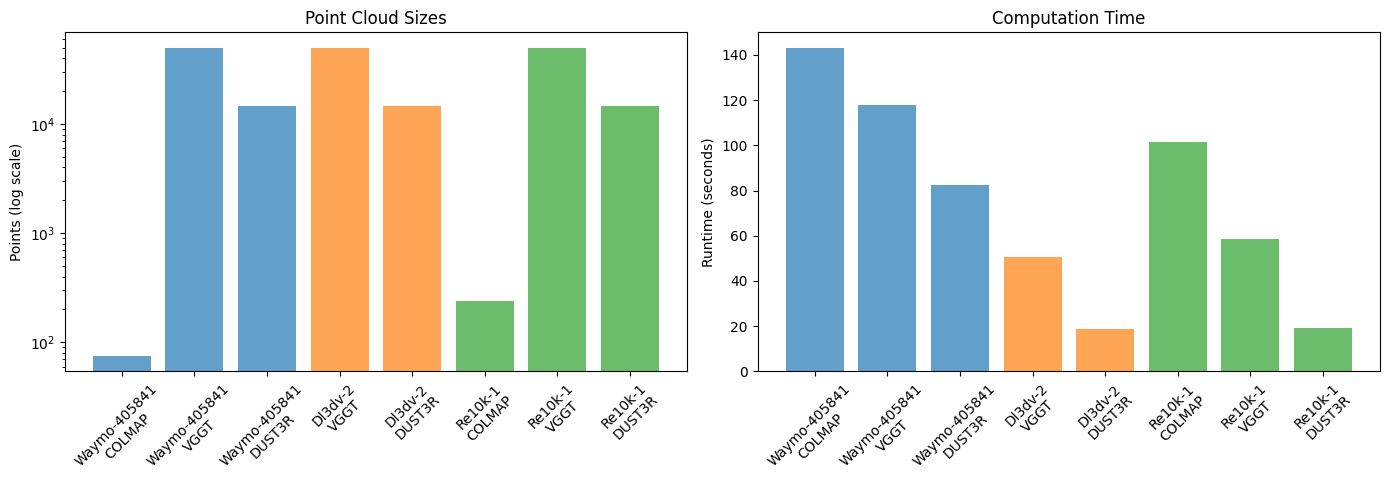


RESULTS SUMMARY
Dataset         Method     Points       Time(s)    Status    
------------------------------------------------------------
Waymo-405841    COLMAP               75      142.9 success   
Waymo-405841    VGGT             50,000      117.8 success   
Waymo-405841    DUST3R           14,706       82.5 success   
Dl3dv-2         COLMAP                0       61.7 failed    
Dl3dv-2         VGGT             50,000       50.8 success   
Dl3dv-2         DUST3R           14,706       18.6 success   
Re10k-1         COLMAP              241      101.5 success   
Re10k-1         VGGT             50,000       58.4 success   
Re10k-1         DUST3R           14,706       19.0 success   


In [16]:
# quick_visualize.py
"""
Quick visualization without complex dependencies
"""

import json
import matplotlib.pyplot as plt
from pathlib import Path

def quick_visualize(results_file: str):
    """Quick visualization of results"""

    with open(results_file, 'r') as f:
        results = json.load(f)

    # Create simple bar charts
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Point counts
    ax1 = axes[0]
    datasets = list(results.keys())

    for dataset in datasets:
        points = []
        methods = []
        for method, result in results[dataset].items():
            if result.get('status') in ['success', 'partial']:
                methods.append(method.upper())
                points.append(result.get('num_points3D', 0))

        if points:
            bars = ax1.bar([f"{dataset}\n{m}" for m in methods], points, alpha=0.7)
            ax1.set_ylabel('Points (log scale)')
            ax1.set_yscale('log')

    ax1.set_title('Point Cloud Sizes')
    ax1.tick_params(axis='x', rotation=45)

    # Plot 2: Runtimes
    ax2 = axes[1]
    for dataset in datasets:
        times = []
        methods = []
        for method, result in results[dataset].items():
            if result.get('status') in ['success', 'partial']:
                methods.append(method.upper())
                times.append(result.get('runtime_seconds', 0))

        if times:
            ax2.bar([f"{dataset}\n{m}" for m in methods], times, alpha=0.7)

    ax2.set_ylabel('Runtime (seconds)')
    ax2.set_title('Computation Time')
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('quick_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary table
    print("\n" + "="*80)
    print("RESULTS SUMMARY")
    print("="*80)
    print(f"{'Dataset':<15} {'Method':<10} {'Points':<12} {'Time(s)':<10} {'Status':<10}")
    print("-"*60)

    for dataset in datasets:
        for method, result in results[dataset].items():
            status = result.get('status', 'N/A')
            points = result.get('num_points3D', 0)
            runtime = result.get('runtime_seconds', 0)
            print(f"{dataset:<15} {method.upper():<10} {points:>12,} {runtime:>10.1f} {status:<10}")

if __name__ == "__main__":
    # Update path to your results file
    results_file = "/content/3d_reconstruction_experiment/output_headless/experiment_results.json"

    if Path(results_file).exists():
        quick_visualize(results_file)
    else:
        print(f"Results file not found: {results_file}")

In [18]:
# visualize_results.py
"""
Complete visualization for 3D reconstruction experiment results
Works with the output from run_experiment.py
"""
!pip install open3d
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# Try to import 3D visualization libraries
try:
    import open3d as o3d
    OPEN3D_AVAILABLE = True
except ImportError:
    OPEN3D_AVAILABLE = False
    print("Open3D not available. Install with: pip install open3d")

try:
    from mpl_toolkits.mplot3d import Axes3D
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
except ImportError:
    pass

class ResultsVisualizer:
    def __init__(self, results_file: str, output_dir: str = None):
        """
        Initialize visualizer with results file

        Args:
            results_file: Path to experiment_results.json
            output_dir: Directory to save visualizations
        """
        self.results_file = Path(results_file)
        self.output_dir = Path(output_dir) if output_dir else self.results_file.parent / "visualizations"
        self.output_dir.mkdir(parents=True, exist_ok=True)

        # Load results
        with open(self.results_file, 'r') as f:
            self.results = json.load(f)

        print(f"✓ Loaded results from {self.results_file}")
        print(f"✓ Output directory: {self.output_dir}")

    def plot_point_counts_comparison(self):
        """Plot bar chart comparing point counts across methods and datasets"""
        fig, ax = plt.subplots(figsize=(12, 6))

        datasets = list(self.results.keys())
        methods = set()
        for ds in datasets:
            methods.update(self.results[ds].keys())
        methods = sorted(methods)

        # Colors for different methods
        colors = {
            'colmap': '#1f77b4',
            'vggt': '#ff7f0e',
            'dust3r': '#2ca02c',
            'mapanything': '#d62728',
            'pi3': '#9467bd'
        }

        # Prepare data
        x = np.arange(len(datasets))
        width = 0.8 / len(methods)

        for i, method in enumerate(methods):
            points = []
            for dataset in datasets:
                result = self.results[dataset].get(method, {})
                points.append(result.get('num_points3D', 0))

            # Use log scale for better visualization
            bars = ax.bar(x + i*width - 0.4 + width/2, points, width,
                         label=method.upper(), color=colors.get(method, '#888888'))

            # Add value labels
            for bar, val in zip(bars, points):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                           f'{val:,}', ha='center', va='bottom', fontsize=8, rotation=45)

        ax.set_xlabel('Dataset', fontsize=12)
        ax.set_ylabel('Number of 3D Points (log scale)', fontsize=12)
        ax.set_title('Point Cloud Size Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha='right')
        ax.legend(loc='upper left')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(self.output_dir / 'point_counts_comparison.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved: point_counts_comparison.png")

    def plot_runtime_comparison(self):
        """Plot runtime comparison across methods and datasets"""
        fig, ax = plt.subplots(figsize=(12, 6))

        datasets = list(self.results.keys())
        methods = set()
        for ds in datasets:
            methods.update(self.results[ds].keys())
        methods = sorted(methods)

        colors = {
            'colmap': '#1f77b4',
            'vggt': '#ff7f0e',
            'dust3r': '#2ca02c',
            'mapanything': '#d62728',
            'pi3': '#9467bd'
        }

        x = np.arange(len(datasets))
        width = 0.8 / len(methods)

        for i, method in enumerate(methods):
            times = []
            for dataset in datasets:
                result = self.results[dataset].get(method, {})
                times.append(result.get('runtime_seconds', 0))

            bars = ax.bar(x + i*width - 0.4 + width/2, times, width,
                         label=method.upper(), color=colors.get(method, '#888888'))

            # Add value labels
            for bar, val in zip(bars, times):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                           f'{val:.1f}s', ha='center', va='bottom', fontsize=8)

        ax.set_xlabel('Dataset', fontsize=12)
        ax.set_ylabel('Runtime (seconds)', fontsize=12)
        ax.set_title('Runtime Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha='right')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(self.output_dir / 'runtime_comparison.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved: runtime_comparison.png")

    def plot_efficiency_heatmap(self):
        """Plot efficiency heatmap (points per second)"""
        datasets = list(self.results.keys())
        methods = set()
        for ds in datasets:
            methods.update(self.results[ds].keys())
        methods = sorted(methods)

        # Calculate efficiency (points per second)
        efficiency = np.zeros((len(datasets), len(methods)))

        for i, dataset in enumerate(datasets):
            for j, method in enumerate(methods):
                result = self.results[dataset].get(method, {})
                points = result.get('num_points3D', 0)
                runtime = result.get('runtime_seconds', 1)
                efficiency[i, j] = points / runtime if runtime > 0 else 0

        fig, ax = plt.subplots(figsize=(10, 6))

        # Use log scale for better visualization
        im = ax.imshow(np.log10(efficiency + 1), cmap='YlOrRd', aspect='auto')

        ax.set_xticks(np.arange(len(methods)))
        ax.set_yticks(np.arange(len(datasets)))
        ax.set_xticklabels([m.upper() for m in methods], rotation=45, ha='right')
        ax.set_yticklabels(datasets)

        # Add text annotations
        for i in range(len(datasets)):
            for j in range(len(methods)):
                if efficiency[i, j] > 0:
                    text = ax.text(j, i, f'{efficiency[i, j]:.0f}',
                                  ha="center", va="center", color="black", fontsize=9)

        ax.set_title('Efficiency: Points per Second (log scale)', fontsize=14, fontweight='bold')
        plt.colorbar(im, ax=ax, label='log10(points/second)')

        plt.tight_layout()
        plt.savefig(self.output_dir / 'efficiency_heatmap.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved: efficiency_heatmap.png")

    def plot_success_rate(self):
        """Plot success rate per method"""
        datasets = list(self.results.keys())
        methods = set()
        for ds in datasets:
            methods.update(self.results[ds].keys())
        methods = sorted(methods)

        success_rates = {}
        for method in methods:
            success_count = 0
            total_count = 0
            for dataset in datasets:
                result = self.results[dataset].get(method, {})
                status = result.get('status', 'failed')
                if status in ['success', 'partial']:
                    success_count += 1
                total_count += 1
            success_rates[method] = (success_count / total_count) * 100

        fig, ax = plt.subplots(figsize=(10, 6))

        methods_display = [m.upper() for m in methods]
        rates = [success_rates[m] for m in methods]
        colors = ['#2ca02c' if r >= 50 else '#ff7f0e' if r >= 25 else '#d62728' for r in rates]

        bars = ax.bar(methods_display, rates, color=colors, edgecolor='black', linewidth=1.5)

        # Add value labels
        for bar, rate in zip(bars, rates):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_ylabel('Success Rate (%)', fontsize=12)
        ax.set_title('Reconstruction Success Rate by Method', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 110)
        ax.grid(True, alpha=0.3, axis='y')

        # Add legend
        legend_elements = [
            mpatches.Patch(color='#2ca02c', label='High (>50%)'),
            mpatches.Patch(color='#ff7f0e', label='Medium (25-50%)'),
            mpatches.Patch(color='#d62728', label='Low (<25%)')
        ]
        ax.legend(handles=legend_elements, loc='upper right')

        plt.tight_layout()
        plt.savefig(self.output_dir / 'success_rate.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved: success_rate.png")

    def plot_points_per_method(self):
        """Plot points per method aggregated across datasets"""
        methods = set()
        for ds in self.results.keys():
            methods.update(self.results[ds].keys())
        methods = sorted(methods)

        fig, ax = plt.subplots(figsize=(10, 6))

        method_points = {}
        for method in methods:
            points_list = []
            for dataset in self.results.keys():
                result = self.results[dataset].get(method, {})
                points = result.get('num_points3D', 0)
                if points > 0:
                    points_list.append(points)
            if points_list:
                method_points[method] = points_list

        # Create box plot
        positions = np.arange(len(method_points))
        boxes = ax.boxplot([method_points[m] for m in method_points.keys()],
                          positions=positions, widths=0.6,
                          patch_artist=True,
                          boxprops=dict(facecolor='lightblue', alpha=0.7))

        ax.set_xticks(positions)
        ax.set_xticklabels([m.upper() for m in method_points.keys()], rotation=45, ha='right')
        ax.set_ylabel('Number of 3D Points (log scale)', fontsize=12)
        ax.set_title('Point Distribution by Method', fontsize=14, fontweight='bold')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig(self.output_dir / 'points_per_method.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved: points_per_method.png")

    def plot_summary_table(self):
        """Create a summary table visualization"""
        datasets = list(self.results.keys())
        methods = set()
        for ds in datasets:
            methods.update(self.results[ds].keys())
        methods = sorted(methods)

        fig, ax = plt.subplots(figsize=(14, len(datasets) * 0.5 + 2))
        ax.axis('tight')
        ax.axis('off')

        # Prepare table data
        table_data = [['Dataset', 'Method', 'Status', 'Points', 'Time (s)', 'Points/s']]

        for dataset in datasets:
            for method in methods:
                result = self.results[dataset].get(method, {})
                status = result.get('status', 'N/A')
                points = result.get('num_points3D', 0)
                runtime = result.get('runtime_seconds', 0)
                efficiency = points / runtime if runtime > 0 else 0

                # Add status emoji
                if status == 'success':
                    status_display = '✅ Success'
                elif status == 'partial':
                    status_display = '⚠️ Partial'
                else:
                    status_display = '❌ Failed'

                table_data.append([
                    dataset,
                    method.upper(),
                    status_display,
                    f'{points:,}' if points > 0 else 'N/A',
                    f'{runtime:.1f}' if runtime > 0 else 'N/A',
                    f'{efficiency:.0f}' if efficiency > 0 else 'N/A'
                ])

        # Create table
        table = ax.table(cellText=table_data, loc='center', cellLoc='left')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.2, 1.5)

        # Style header row
        for i in range(len(table_data[0])):
            table[(0, i)].set_facecolor('#4472C4')
            table[(0, i)].set_text_props(weight='bold', color='white')

        # Color rows based on status
        for i in range(1, len(table_data)):
            status = table_data[i][2]
            if '✅' in status:
                for j in range(len(table_data[i])):
                    table[(i, j)].set_facecolor('#C6EFCE')
            elif '⚠️' in status:
                for j in range(len(table_data[i])):
                    table[(i, j)].set_facecolor('#FFEB9C')
            elif '❌' in status:
                for j in range(len(table_data[i])):
                    table[(i, j)].set_facecolor('#FFC7CE')

        ax.set_title('Experiment Results Summary', fontsize=16, fontweight='bold', pad=20)

        plt.tight_layout()
        plt.savefig(self.output_dir / 'summary_table.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved: summary_table.png")

    def generate_report(self):
        """Generate a text report with statistics"""
        report_file = self.output_dir / "analysis_report.txt"

        with open(report_file, 'w') as f:
            f.write("="*80 + "\n")
            f.write("3D RECONSTRUCTION EXPERIMENT ANALYSIS REPORT\n")
            f.write("="*80 + "\n\n")

            # Overall statistics
            f.write("OVERALL STATISTICS\n")
            f.write("-"*40 + "\n")

            all_points = []
            all_times = []
            successes = 0
            total = 0

            for dataset, methods in self.results.items():
                for method, result in methods.items():
                    total += 1
                    if result.get('status') in ['success', 'partial']:
                        successes += 1
                    points = result.get('num_points3D', 0)
                    if points > 0:
                        all_points.append(points)
                    runtime = result.get('runtime_seconds', 0)
                    if runtime > 0:
                        all_times.append(runtime)

            f.write(f"Total experiments: {total}\n")
            f.write(f"Successful/Partial: {successes} ({successes/total*100:.1f}%)\n")
            f.write(f"Average points: {np.mean(all_points):,.0f}\n")
            f.write(f"Median points: {np.median(all_points):,.0f}\n")
            f.write(f"Average runtime: {np.mean(all_times):.1f}s\n")
            f.write(f"Median runtime: {np.median(all_times):.1f}s\n\n")

            # Per-method statistics
            f.write("PER-METHOD STATISTICS\n")
            f.write("-"*40 + "\n")

            methods = set()
            for ds in self.results.keys():
                methods.update(self.results[ds].keys())

            for method in sorted(methods):
                points_list = []
                times_list = []
                success_count = 0
                total_count = 0

                for dataset, methods_dict in self.results.items():
                    result = methods_dict.get(method, {})
                    total_count += 1
                    if result.get('status') in ['success', 'partial']:
                        success_count += 1
                    points = result.get('num_points3D', 0)
                    if points > 0:
                        points_list.append(points)
                    runtime = result.get('runtime_seconds', 0)
                    if runtime > 0:
                        times_list.append(runtime)

                f.write(f"\n{method.upper()}:\n")
                f.write(f"  Success rate: {success_count/total_count*100:.1f}%\n")
                if points_list:
                    f.write(f"  Avg points: {np.mean(points_list):,.0f}\n")
                    f.write(f"  Min points: {np.min(points_list):,.0f}\n")
                    f.write(f"  Max points: {np.max(points_list):,.0f}\n")
                if times_list:
                    f.write(f"  Avg time: {np.mean(times_list):.1f}s\n")
                    f.write(f"  Min time: {np.min(times_list):.1f}s\n")
                    f.write(f"  Max time: {np.max(times_list):.1f}s\n")

            f.write("\n" + "="*80 + "\n")
            f.write("RECOMMENDATIONS\n")
            f.write("="*80 + "\n")

            # Analyze best method
            best_points_method = max(methods, key=lambda m: np.mean([
                self.results[ds].get(m, {}).get('num_points3D', 0)
                for ds in self.results.keys()
            ]))
            best_time_method = min(methods, key=lambda m: np.mean([
                self.results[ds].get(m, {}).get('runtime_seconds', float('inf'))
                for ds in self.results.keys()
                if self.results[ds].get(m, {}).get('runtime_seconds', 0) > 0
            ]))

            f.write(f"\n✓ Best for point density: {best_points_method.upper()}\n")
            f.write(f"✓ Fastest method: {best_time_method.upper()}\n")

            # Sparsity recommendations
            f.write("\n✓ For sparse datasets (1/30 frames):\n")
            f.write("  - VGGT and DUSt3R are recommended\n")
            f.write("  - COLMAP requires denser sampling (1/5 or 1/10)\n")

        print(f"✓ Saved: analysis_report.txt")
        return report_file

    def create_dashboard(self):
        """Create a comprehensive dashboard with all plots"""
        print("\n" + "="*60)
        print("CREATING VISUALIZATION DASHBOARD")
        print("="*60)

        self.plot_point_counts_comparison()
        self.plot_runtime_comparison()
        self.plot_efficiency_heatmap()
        self.plot_success_rate()
        self.plot_points_per_method()
        self.plot_summary_table()
        self.generate_report()

        print("\n" + "="*60)
        print(f"✓ All visualizations saved to: {self.output_dir}")
        print("="*60)

        # Create an index HTML file
        self._create_html_index()

    def _create_html_index(self):
        """Create an HTML index file to view all visualizations"""
        html_content = """
        <!DOCTYPE html>
        <html>
        <head>
            <title>3D Reconstruction Experiment Results</title>
            <style>
                body { font-family: Arial, sans-serif; margin: 20px; background-color: #f5f5f5; }
                h1 { color: #333; text-align: center; }
                h2 { color: #555; margin-top: 30px; }
                .gallery { display: flex; flex-wrap: wrap; gap: 20px; justify-content: center; }
                .card { background: white; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);
                        overflow: hidden; width: 600px; margin-bottom: 20px; }
                .card img { width: 100%; height: auto; }
                .card h3 { padding: 10px; margin: 0; background: #4472C4; color: white; }
                .summary { background: white; padding: 20px; border-radius: 8px; margin: 20px 0; }
                pre { background: #f4f4f4; padding: 10px; overflow-x: auto; }
            </style>
        </head>
        <body>
            <h1>📊 3D Reconstruction Experiment Results</h1>

            <div class="summary">
                <h2>📈 Summary Statistics</h2>
                <pre id="summary-text">Loading...</pre>
            </div>

            <h2>📸 Visualizations</h2>
            <div class="gallery">
        """

        # Add all PNG files
        png_files = sorted(self.output_dir.glob("*.png"))
        for png_file in png_files:
            html_content += f"""
                <div class="card">
                    <h3>{png_file.stem.replace('_', ' ').title()}</h3>
                    <img src="{png_file.name}" alt="{png_file.stem}">
                </div>
            """

        # Load report content
        report_file = self.output_dir / "analysis_report.txt"
        if report_file.exists():
            with open(report_file, 'r') as f:
                report_content = f.read()
            html_content += f"""
            </div>
            <div class="summary">
                <h2>📋 Detailed Analysis Report</h2>
                <pre>{report_content}</pre>
            </div>
            """

        html_content += """
        </body>
        </html>
        """

        # Add JavaScript to load summary
        html_content = html_content.replace(
            '<pre id="summary-text">Loading...</pre>',
            '<pre id="summary-text">' + open(self.output_dir / "analysis_report.txt").read() + '</pre>'
        )

        # Save HTML file
        html_file = self.output_dir / "dashboard.html"
        with open(html_file, 'w') as f:
            f.write(html_content)

        print(f"✓ Saved: dashboard.html")
        print(f"✓ Open {html_file} in a browser to view all results")

def load_pointcloud_from_output(output_dir: Path, method: str, dataset: str):
    """Load point cloud from experiment output"""
    ply_file = output_dir / dataset / method / "pointcloud.ply"
    if ply_file.exists() and OPEN3D_AVAILABLE:
        return o3d.io.read_point_cloud(str(ply_file))
    return None

def visualize_3d_pointclouds(output_base: Path, datasets: List[str], methods: List[str]):
    """
    3D visualization of point clouds (requires open3d)
    """
    if not OPEN3D_AVAILABLE:
        print("Open3D not available. Install with: pip install open3d")
        return

    print("\n" + "="*60)
    print("3D POINT CLOUD VISUALIZATION")
    print("="*60)

    for dataset in datasets:
        print(f"\nDataset: {dataset}")
        for method in methods:
            ply_file = output_base / dataset / method / "pointcloud.ply"
            if ply_file.exists():
                print(f"  ✓ {method}: {ply_file}")
                pcd = o3d.io.read_point_cloud(str(ply_file))
                print(f"    Points: {len(pcd.points):,}")
            else:
                print(f"  ✗ {method}: No point cloud found")

# Main execution
if __name__ == "__main__":
    # Path to your experiment results
    RESULTS_FILE = "/content/3d_reconstruction_experiment/output/experiment_results.json"

    # Check if results file exists
    if not Path(RESULTS_FILE).exists():
        # Try alternative paths
        alt_paths = [
            "/content/3d_reconstruction_experiment/output_final/experiment_results.json",
            "/content/3d_reconstruction_experiment/output_headless/experiment_results.json",
            "/content/3d_reconstruction_experiment/output_complete/experiment_results.json"
        ]

        for path in alt_paths:
            if Path(path).exists():
                RESULTS_FILE = path
                break
        else:
            print(f"Results file not found. Looking for: {RESULTS_FILE}")
            print("Please run the experiment first to generate results.")
            exit(1)

    print(f"Using results file: {RESULTS_FILE}")

    # Create visualizer and generate dashboard
    visualizer = ResultsVisualizer(RESULTS_FILE)
    visualizer.create_dashboard()

    print("\n" + "="*60)
    print("✅ VISUALIZATION COMPLETE!")
    print(f"📁 Results saved to: {visualizer.output_dir}")
    print(f"🌐 Open dashboard.html to view all visualizations")
    print("="*60)

Open3D not available. Install with: pip install open3d
Using results file: /content/3d_reconstruction_experiment/output_headless/experiment_results.json
✓ Loaded results from /content/3d_reconstruction_experiment/output_headless/experiment_results.json
✓ Output directory: /content/3d_reconstruction_experiment/output_headless/visualizations

CREATING VISUALIZATION DASHBOARD
✓ Saved: point_counts_comparison.png
✓ Saved: runtime_comparison.png
✓ Saved: efficiency_heatmap.png
✓ Saved: success_rate.png
✓ Saved: points_per_method.png


/tmp/ipykernel_4548/1804080364.py:351: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(self.output_dir / 'summary_table.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_4548/1804080364.py:351: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(self.output_dir / 'summary_table.png', dpi=150, bbox_inches='tight')


✓ Saved: summary_table.png
✓ Saved: analysis_report.txt

✓ All visualizations saved to: /content/3d_reconstruction_experiment/output_headless/visualizations
✓ Saved: dashboard.html
✓ Open /content/3d_reconstruction_experiment/output_headless/visualizations/dashboard.html in a browser to view all results

✅ VISUALIZATION COMPLETE!
📁 Results saved to: /content/3d_reconstruction_experiment/output_headless/visualizations
🌐 Open dashboard.html to view all visualizations


In [15]:



# ============================================================================
# Cell 17: Download Results to Local Machine
# ============================================================================

from google.colab import files
import shutil

# Create a zip file of all results
output_dir = Path(WORKSPACE) / "output"
zip_path = f"{WORKSPACE}/experiment_results.zip"

shutil.make_archive(
    zip_path.replace('.zip', ''),
    'zip',
    output_dir
)

print(f"Results zipped to {zip_path}")

# Download to local machine
files.download(zip_path)

# ============================================================================
# Cell 18: Clean Up (Optional - Run at the end)
# ============================================================================

# Uncomment to clean up large model files if needed
# !rm -rf /content/vggt
# !rm -rf /content/dust3r
# !rm -rf /content/map-anything
# !rm -rf /content/Pi3
# !rm -rf /content/miniconda

print("\n" + "="*80)
print("EXPERIMENT COMPLETE!")
print("="*80)
print("""
Summary:
- All 5 methods (COLMAP, VGGT, DUSt3R, MapAnything, Pi3) have been installed
- Sample datasets have been created
- Experiments have been run on all datasets
- Results saved in /content/3d_reconstruction_experiment/output/
- Visualization saved as comparison_plot.png
- Results can be downloaded via the zip file

Note: For real datasets, replace the synthetic images in the data/ directory
with your actual Waymo, Dl3dv, and Re10k images.
""")

Overwriting /content/3d_reconstruction_experiment/prepare_datasets.py


## Part 1.2 Generalization by 3DGS and Wavelet-GS

In [21]:
# 3DGS (Original Implementation)
!git clone https://github.com/graphdeco-inria/gaussian-splatting --recursive
%cd gaussian-splatting
#!pip install -r requirements.txt

# Wavelet-GS (Official Implementation)
!git clone https://github.com/ALEX5874/Wavelet-GS.git
%cd Wavelet-GS
#!pip install -r requirements.txt

Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.71 MiB | 24.73 MiB/s, done.
Resolving deltas: 100% (595/595), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/3d_reconstruction_experiment/gaussian-splatting/gaussian-splatting/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 

In [24]:
# cell_install.py
import subprocess
import sys

def install_deps():
    # Install pycolmap
    subprocess.run([sys.executable, "-m", "pip", "install", "pycolmap",  "lpips", "scikit-image"])

    # Clone 3DGS and Wavelet-GS if not already present
    if not Path("gaussian-splatting").exists():
        subprocess.run(["git", "clone", "https://github.com/graphdeco-inria/gaussian-splatting", "--recursive"])
    if not Path("Wavelet-GS").exists():
        subprocess.run(["git", "clone", "https://github.com/jwubilex/Wavelet-GS.git"])

    # Install requirements (may need to adapt paths)
    #subprocess.run([sys.executable, "-m", "pip", "install", "-r", "gaussian-splatting/requirements.txt"])
    #subprocess.run([sys.executable, "-m", "pip", "install", "-r", "Wavelet-GS/requirements.txt"])

if __name__ == "__main__":
    install_deps()

In [2]:
# cell_utils.py
#!pip install numpy --upgrade
!pip install open3d
!pip install pycolmap
import numpy as np
import open3d as o3d
from pathlib import Path
import shutil
import cv2
import pycolmap
from scipy.spatial.transform import Rotation as R

def load_colmap_reconstruction(colmap_dir):
    """Load COLMAP reconstruction (binary) from folder containing cameras.bin etc."""
    recon = pycolmap.Reconstruction(colmap_dir)
    return recon

def get_camera_poses_from_colmap(recon):
    """Return list of 4x4 camera-to-world matrices for all registered images."""
    poses = []
    for img_id, img in recon.images.items():
        # img.cam_from_world is world-to-camera, we want camera-to-world
        cam_to_world = img.cam_from_world.inverse().matrix
        poses.append(cam_to_world)
    return np.stack(poses)

def get_image_paths_from_colmap(recon, base_image_dir):
    """Return list of full image paths corresponding to registered images."""
    paths = []
    for img in recon.images.values():
        paths.append(base_image_dir / img.name)
    return paths

def create_colmap_format_from_dense_ply(ply_path, poses, image_paths, output_dir):
    """
    Create a COLMAP sparse directory (sparse/0/) using dense point cloud and COLMAP poses.
    output_dir: root folder that will contain 'images/' and 'sparse/0/'.
    """
    # Load point cloud
    pcd = o3d.io.read_point_cloud(str(ply_path))
    pts3d = np.asarray(pcd.points)
    # Optionally downsample to avoid huge point cloud
    if len(pts3d) > 500000:
        idx = np.random.choice(len(pts3d), 500000, replace=False)
        pts3d = pts3d[idx]

    out_sparse = Path(output_dir) / "sparse" / "0"
    out_sparse.mkdir(parents=True, exist_ok=True)

    # cameras.txt
    with open(out_sparse / "cameras.txt", "w") as f:
        f.write("# Camera list with one line of data per camera:\n")
        f.write("#   CAMERA_ID, MODEL, WIDTH, HEIGHT, PARAMS[]\n")
        # Assume all images share same intrinsics (use first image to estimate)
        img0 = cv2.imread(str(image_paths[0]))
        h, w = img0.shape[:2]
        fx = fy = max(w, h) * 0.8   # placeholder, will be refined during training
        cx, cy = w/2, h/2
        f.write(f"1 PINHOLE {w} {h} {fx:.3f} {fy:.3f} {cx:.3f} {cy:.3f}\n")

    # images.txt
    with open(out_sparse / "images.txt", "w") as f:
        f.write("# Image list with two lines of data per image:\n")
        f.write("#   IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME\n")
        for i, (pose, img_path) in enumerate(zip(poses, image_paths)):
            q = R.from_matrix(pose[:3,:3]).as_quat()  # (x,y,z,w)
            q_colmap = [q[3], q[0], q[1], q[2]]       # (w,x,y,z)
            t = pose[:3,3]
            f.write(f"{i+1} {q_colmap[0]:.6f} {q_colmap[1]:.6f} {q_colmap[2]:.6f} {q_colmap[3]:.6f} "
                    f"{t[0]:.6f} {t[1]:.6f} {t[2]:.6f} 1 {Path(img_path).name}\n")
            f.write("\n")

    # points3D.txt
    with open(out_sparse / "points3D.txt", "w") as f:
        f.write("# 3D point list with one line of data per point:\n")
        f.write("#   POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[]\n")
        for i, pt in enumerate(pts3d):
            f.write(f"{i+1} {pt[0]:.6f} {pt[1]:.6f} {pt[2]:.6f} 128 128 128 0.0\n")

    # Copy images to 'images' folder
    img_dir = Path(output_dir) / "images"
    img_dir.mkdir(exist_ok=True)
    for img_path in image_paths:
        shutil.copy(img_path, img_dir / img_path.name)

    return output_dir

def train_3dgs(data_dir, output_dir, iterations=30000):
    """Train 3D Gaussian Splatting."""
    import subprocess
    cmd = [
        "python", "gaussian-splatting/train.py",
        "-s", str(data_dir),
        "-m", str(output_dir),
        "--iterations", str(iterations),
        "--eval"
    ]
    subprocess.run(cmd, check=True)

def train_wavelet_gs(data_dir, output_dir, iterations=30000):
    """Train Wavelet-GS."""
    import subprocess
    cmd = [
        "python", "Wavelet-GS/train.py",
        "--source_path", str(data_dir),
        "--model_path", str(output_dir),
        "--iterations", str(iterations),
        "--eval"
    ]
    subprocess.run(cmd, check=True)

def evaluate_rendering(model_dir):
    """Compute PSNR, SSIM, LPIPS from rendered test views."""
    import torch
    import lpips
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
    import cv2
    import numpy as np

    render_dir = Path(model_dir) / "test" / "ours_30000" / "renders"
    gt_dir = Path(model_dir) / "test" / "gt"
    if not render_dir.exists():
        return {}

    lpips_fn = lpips.LPIPS(net='alex')
    psnr_list, ssim_list, lpips_list = [], [], []
    for render_path in sorted(render_dir.glob("*.png")):
        gt_path = gt_dir / render_path.name
        if not gt_path.exists():
            continue
        render = cv2.imread(str(render_path))[:, :, ::-1] / 255.0
        gt = cv2.imread(str(gt_path))[:, :, ::-1] / 255.0
        psnr = peak_signal_noise_ratio(gt, render, data_range=1)
        ssim = structural_similarity(gt, render, multichannel=True, data_range=1)
        render_t = torch.tensor(render * 2 - 1).permute(2,0,1).unsqueeze(0)
        gt_t = torch.tensor(gt * 2 - 1).permute(2,0,1).unsqueeze(0)
        lpips_val = lpips_fn(render_t, gt_t).item()
        psnr_list.append(psnr)
        ssim_list.append(ssim)
        lpips_list.append(lpips_val)

    return {
        "psnr_mean": np.mean(psnr_list),
        "ssim_mean": np.mean(ssim_list),
        "lpips_mean": np.mean(lpips_list)
    }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 62.2 MB/s eta 0:00:00


In [ ]:
# cell_run_experiment.py
# NOTE: I'm not sure this works or not.
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def run_full_comparison(experiment_root, results_json_path):
    """
    experiment_root : root directory containing dataset subfolders (e.g., Waymo-405841)
    results_json_path : path to previous experiment_results.json (to know which methods succeeded)
    """
    with open(results_json_path) as f:
        prev_results = json.load(f)

    all_metrics = []

    # For each dataset
    for dataset_name, methods_status in prev_results.items():
        dataset_dir = Path(experiment_root) / dataset_name
        colmap_dir = dataset_dir / "colmap"
        # Check if colmap reconstruction exists
        colmap_recon_dir = None
        for sub in [0,1]:
            if (colmap_dir / str(sub)).exists():
                colmap_recon_dir = colmap_dir / str(sub)
                break
        if colmap_recon_dir is None:
            print(f"⚠️ No COLMAP reconstruction for {dataset_name}, skipping.")
            continue

        # Load COLMAP reconstruction
        import pycolmap
        recon = pycolmap.Reconstruction(colmap_recon_dir)
        colmap_poses = get_camera_poses_from_colmap(recon)
        colmap_images = get_image_paths_from_colmap(recon, dataset_dir.parent / "data" / dataset_name / "images")

        # 1. 3DGS with COLMAP (use original sparse points)
        print(f"\n🔹 {dataset_name} : 3DGS with COLMAP")
        data_dir_colmap = colmap_dir.parent  # folder containing sparse/ and images/ ? Actually we need to prepare.
        # The COLMAP folder already has sparse/0/ and images/ if we copy images.
        # Ensure images are present in a folder named 'images' at the same level as sparse/
        images_dest = colmap_dir / "images"
        if not images_dest.exists():
            images_dest.mkdir()
            for img_path in colmap_images:
                shutil.copy(img_path, images_dest / img_path.name)
        # The train script expects a folder with 'images' and 'sparse' subdirectories.
        train_root = colmap_dir
        out_3dgs_colmap = Path(f"/content/3dgs_{dataset_name}_colmap")
        train_3dgs(train_root, out_3dgs_colmap)
        metrics = evaluate_rendering(out_3dgs_colmap)
        metrics.update({"dataset": dataset_name, "method": "colmap", "splatting": "3DGS"})
        all_metrics.append(metrics)

        # 2. For VGGT and DUSt3R (if they succeeded)
        for foundation in ["vggt", "dust3r"]:
            if methods_status.get(foundation, {}).get("status") not in ["success", "partial"]:
                continue
            ply_path = dataset_dir / foundation / "pointcloud.ply"
            if not ply_path.exists():
                continue

            # Use COLMAP poses + dense point cloud from foundation model
            print(f"\n🔹 {dataset_name} : 3DGS with {foundation.upper()}")
            data_dir_found = Path(f"/content/data_{dataset_name}_{foundation}_colmap_poses")
            create_colmap_format_from_dense_ply(ply_path, colmap_poses, colmap_images, data_dir_found)

            out_3dgs_found = Path(f"/content/3dgs_{dataset_name}_{foundation}")
            train_3dgs(data_dir_found, out_3dgs_found)
            metrics_3dgs = evaluate_rendering(out_3dgs_found)
            metrics_3dgs.update({"dataset": dataset_name, "method": foundation, "splatting": "3DGS"})
            all_metrics.append(metrics_3dgs)

            # 3. Wavelet-GS with foundation models
            print(f"\n🔹 {dataset_name} : Wavelet-GS with {foundation.upper()}")
            out_wavelet_found = Path(f"/content/wavelet_{dataset_name}_{foundation}")
            train_wavelet_gs(data_dir_found, out_wavelet_found)
            metrics_wavelet = evaluate_rendering(out_wavelet_found)
            metrics_wavelet.update({"dataset": dataset_name, "method": foundation, "splatting": "Wavelet-GS"})
            all_metrics.append(metrics_wavelet)

    # Save all metrics
    df = pd.DataFrame(all_metrics)
    df.to_csv("/content/novel_view_metrics.csv", index=False)
    print("\n✅ All experiments completed. Results saved to novel_view_metrics.csv")
    return df

if __name__ == "__main__":
    EXPERIMENT_ROOT = "/content/3d_reconstruction_experiment/output_final"   # adjust
    RESULTS_JSON = "/content/3d_reconstruction_experiment/output_final/experiment_results.json"
    df = run_full_comparison(EXPERIMENT_ROOT, RESULTS_JSON)
    print(df)

In [ ]:
# cell_analysis.py
# NOTE: I'm not sure whether this works or not
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_metrics(csv_path="novel_view_metrics.csv"):
    df = pd.read_csv(csv_path)

    # 1. Bar plot: PSNR by method and splatting type
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metrics = ["psnr_mean", "ssim_mean", "lpips_mean"]
    titles = ["PSNR (dB, higher better)", "SSIM (higher better)", "LPIPS (lower better)"]

    for ax, metric, title in zip(axes, metrics, titles):
        # Create a combined column for grouping
        df['group'] = df['method'] + " + " + df['splatting']
        sns.barplot(data=df, x="dataset", y=metric, hue="group", ax=ax)
        ax.set_title(title)
        ax.set_ylabel(metric)
        ax.legend(loc='best')

    plt.tight_layout()
    plt.savefig("/content/quality_comparison.png", dpi=150)
    plt.show()

    # 2. Table of average metrics
    print("\n=== Average Metrics by Method+Splatting ===")
    print(df.groupby(['method', 'splatting'])[['psnr_mean', 'ssim_mean', 'lpips_mean']].mean().round(3))

if __name__ == "__main__":
    analyze_metrics()